# XGBoost training and testing

### 1. Introduction


In this notebook, we are going to test and try an XGBoost model.

### 2. Librairies


In [12]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

### 3. Load Data, Filter and Pivot to Wide

In [13]:
# 1 : Load
df_long = pd.read_csv('../Data/dataREanonymized_long.csv')

# 2 : Finding the subjects with non-null discharge_mrs values
valid_subjects = df_long[
    (df_long['variable'] == 'discharge_mrs') &
    (df_long['Value'].notna())
]['subject_id'].unique()

# 3 : Filter the DataFrame to only include valid subjects
df_long_filtered = df_long[df_long['subject_id'].isin(valid_subjects)]

# 4 : Pivot to Wide format
df_wide = df_long_filtered.pivot(index='subject_id', columns='variable', values='Value').reset_index()

# 5 : Keep only rows where stroke_type is "ischemic"
df_wide = df_wide[df_wide['stroke_type'] == 'ischemic']
df_wide = df_wide[df_wide['thrombolysis'] == '1']


C:\Users\2432741\AppData\Local\Temp\ipykernel_22364\890118506.py:2: DtypeWarning: Columns (0: Value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv('../Data/dataREanonymized_long.csv')


### 4. Target variable extraction & Features

In [26]:
# 1. Extraction of the target variable (y)
target_raw = pd.to_numeric(df_wide['three_m_mrs'], errors='coerce')
y = (target_raw <= 2).astype(int)

# 2. Isolation of the features (X)
X = df_wide.drop(columns=['three_m_mrs', 'stroke_type', 'door_to_groin', 'thrombolysis', 'subject_id',
                          'bleeding_source', 'bleeding_volume_value', 'department_type', 'dysphagia_screening_type',
                          'gender', 'hospitalized_in', 'imaging_type', 'no_thrombolysis_reason',
                          'stroke_mimics_diagnosis'])

# Numerical conversion of the features to ensure they are all numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Delete columns that are entirely NaN to prevent KNN Imputer from silently dropping them later
X = X.dropna(how='all', axis=1)
pd.set_option('display.max_columns', None)
X.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 1992 entries, 4 to 9510
Data columns (total 51 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   age                                                    1992 non-null   int64  
 1   before_onset_antidiabetics                             1164 non-null   float64
 2   before_onset_cilostazol                                1164 non-null   float64
 3   before_onset_clopidrogel                               1164 non-null   float64
 4   before_onset_dipyridamol                               1164 non-null   float64
 5   before_onset_prasugrel                                 1164 non-null   float64
 6   before_onset_ticagrelor                                1164 non-null   float64
 7   before_onset_ticlopidine                               1164 non-null   float64
 8   before_onset_warfarin                                  1164 non-

### 5. Split of the Data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 6. Imputing the Data

In [16]:
knn_imputer = KNNImputer(n_neighbors=5)

X_train_clean = pd.DataFrame(knn_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_clean = pd.DataFrame(knn_imputer.transform(X_test), columns=X_test.columns)

### 7. Class balancing

In [17]:
count_zeros = (y_train == 0).sum()
count_ones = (y_train == 1).sum()
ratio_poids = count_zeros / count_ones

### 8. Hyperparameter grid & Random Search

In [18]:
xgboost_grid = {
    'n_estimators': [100, 300, 500],       
    'learning_rate': [0.01, 0.05, 0.1],     
    'max_depth': [3, 5, 7],                 
    'subsample': [0.7, 0.9, 1.0],           
    'colsample_bytree': [0.7, 0.9, 1.0]     
}

model_xgb = XGBClassifier(
    scale_pos_weight=ratio_poids, 
    eval_metric='logloss', 
    random_state=42,
    n_jobs=-1
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=model_xgb, 
    param_distributions=xgboost_grid, 
    n_iter=10,                 
    cv=cv_strategy,            
    random_state=42, 
    n_jobs=-1                  
)

In [19]:
random_search.fit(X_train_clean, y_train)

best_model = random_search.best_estimator_
print("The best parameters are :", random_search.best_params_)

The best parameters are : {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


### 9. Accuracy

In [20]:
test_score = best_model.score(X_test_clean, y_test)
print(f"\nScore d'exactitude (Accuracy) final sur le Test Set : {test_score * 100:.2f}%")


Score d'exactitude (Accuracy) final sur le Test Set : 85.71%


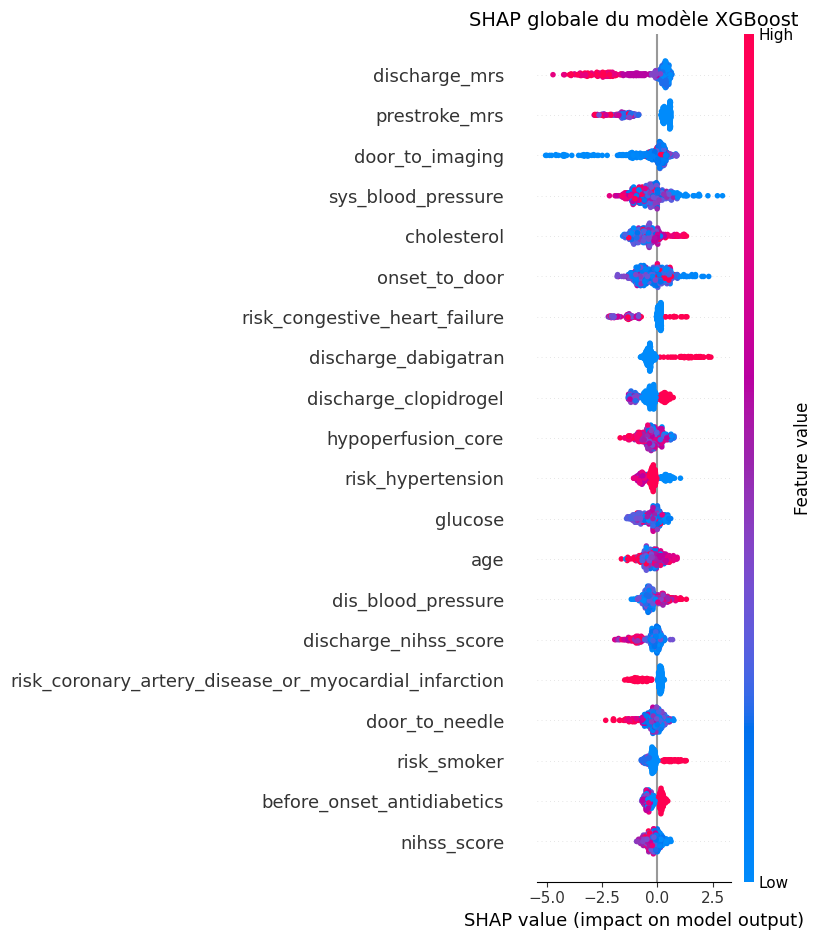

In [21]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test_clean)

plt.figure()
plt.title("SHAP globale du modèle XGBoost", fontsize=14)

shap.summary_plot(shap_values, X_test_clean, show=False)

plt.show()

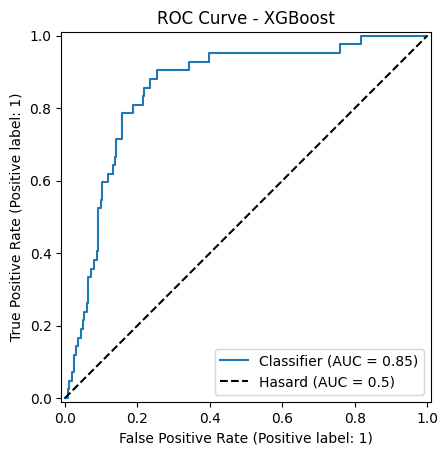

In [22]:
# y_pred = best_model.predict(X_test_clean)
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
# plt.title("Confusion Matrix - XGBoost")
# plt.show()

y_probs = best_model.predict_proba(X_test_clean)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_probs,)
plt.plot([0, 1], [0, 1], "k--", label="Hasard (AUC = 0.5)")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()